In [11]:
import skimage
import numpy as np
import pandas as pd
from skimage import io
import matplotlib.pyplot as plt


%matplotlib inline

In [3]:

cat = io.imread('datasets/cat.png')
dog = io.imread("datasets/dog.png")
df = pd.DataFrame(['Cat','Dog'],columns=['Image'])

print(cat.shape,dog.shape)

(168, 300, 3) (168, 300, 3)


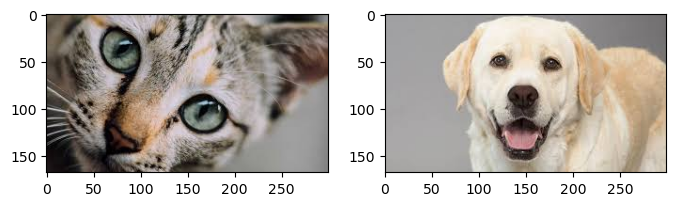

In [5]:
fig = plt.figure(figsize=(8,4))
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(cat)
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(dog)

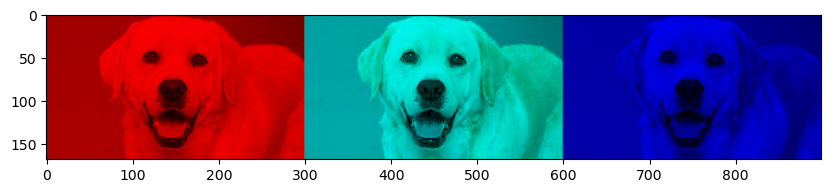

In [9]:

dog_r = dog.copy()
dog_r[:,:,1] = dog_r[:,:,2] = 0
dog_g = dog.copy()
dog_g[:,:,0] = dog_r[:,:,2] = 0
dog_b = dog.copy()
dog_b[:,:,0] = dog_b[:,:,1] = 0

plot_image = np.concatenate((dog_r,dog_g,dog_b),axis=1)
plt.figure(figsize=(10,4))
plt.imshow(plot_image)

In [10]:
dog_r

array([[[160,   0,   0],
        [160,   0,   0],
        [160,   0,   0],
        ...,
        [113,   0,   0],
        [113,   0,   0],
        [112,   0,   0]],

       [[160,   0,   0],
        [160,   0,   0],
        [160,   0,   0],
        ...,
        [113,   0,   0],
        [113,   0,   0],
        [112,   0,   0]],

       [[160,   0,   0],
        [160,   0,   0],
        [160,   0,   0],
        ...,
        [113,   0,   0],
        [113,   0,   0],
        [112,   0,   0]],

       ...,

       [[165,   0,   0],
        [165,   0,   0],
        [165,   0,   0],
        ...,
        [212,   0,   0],
        [211,   0,   0],
        [210,   0,   0]],

       [[165,   0,   0],
        [165,   0,   0],
        [165,   0,   0],
        ...,
        [210,   0,   0],
        [210,   0,   0],
        [209,   0,   0]],

       [[164,   0,   0],
        [164,   0,   0],
        [164,   0,   0],
        ...,
        [209,   0,   0],
        [209,   0,   0],
        [209,   0,   0]]

In [13]:
from skimage.color import rgb2gray

cgs = rgb2gray(cat)
dgs = rgb2gray(dog)

print('Image shape:',cgs.shape,'\n')

print('2D image pixel map')
print(np.round(cgs,2),'\n')

print('Flatten pixel map:',(np.round(cgs.flatten(),2)))


Image shape: (168, 300) 

2D image pixel map
[[0.42 0.41 0.41 ... 0.5  0.52 0.53]
 [0.41 0.41 0.4  ... 0.51 0.52 0.54]
 [0.4  0.4  0.4  ... 0.52 0.54 0.55]
 ...
 [0.11 0.11 0.1  ... 0.51 0.51 0.51]
 [0.11 0.11 0.1  ... 0.51 0.51 0.51]
 [0.11 0.11 0.1  ... 0.51 0.51 0.51]] 

Flatten pixel map: [0.42 0.41 0.41 ... 0.51 0.51 0.51]


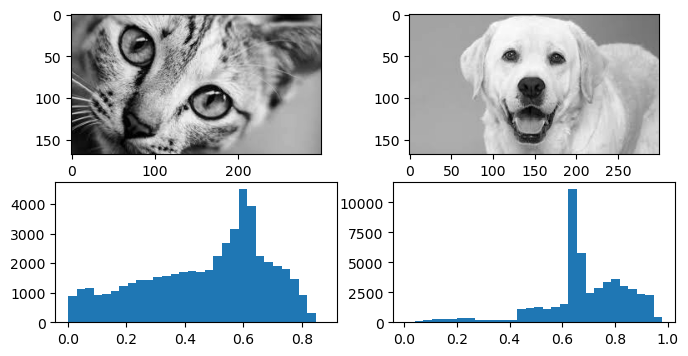

In [14]:
fig = plt.figure(figsize=(8,4))
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(cgs,cmap='gray')
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(dgs,cmap='gray')
ax3 = fig.add_subplot(2,2,3)
c_freq , c_bins , c_pathces = ax3.hist(cgs.flatten(),bins=30)
ax4 = fig.add_subplot(2,2,4)
d_freq,d_bins,d_patches = ax4.hist(dgs.flatten(),bins=30)

In [17]:
from scipy.stats import describe

cat_rgb = cat.reshape((168*300), 3).T
dog_rgb = cat.reshape((168*300),3).T

cs = describe(cat_rgb,axis=1)
ds = describe(dog_rgb,axis=1)

cat_rgb_range = cs.minmax[1]-cs.minmax[0]
dog_rgb_range = ds.minmax[1]-cs.minmax[0]

rgb_range_df = pd.DataFrame([cat_rgb_range,dog_rgb_range],
                            columns=['R_range','G_range','B_range'])
pd.concat([df,rgb_range_df],axis=1)


,Image,R_range,G_range,B_range
0,Cat,240,223,235
1,Dog,240,223,235


In [22]:


cat_stats = np.array([np.round(cs.mean,2),np.round(cs.variance,2),
                      np.round(cs.kurtosis,2),np.round(cs.skewness,2),
                      np.round(np.median(cat_rgb,axis=1),2)]).flatten()

dog_stats = np.array([np.round(ds.mean,2),np.round(ds.variance,2),
                      np.round(ds.kurtosis,2),np.round(ds.skewness,2),
                      np.round(np.median(dog_rgb,axis=1),2)]).flatten()

stats_df = pd.DataFrame([cat_stats, dog_stats],
                        columns=['R_mean', 'G_mean', 'B_mean', 
                                 'R_var', 'G_var', 'B_var',
                                 'R_kurt', 'G_kurt', 'B_kurt',
                                 'R_skew', 'G_skew', 'B_skew',
                                 'R_med', 'G_med', 'B_med'])
pd.concat([df, stats_df], axis=1)


,Image,R_mean,G_mean,B_mean,R_var,G_var,B_var,R_kurt,G_kurt,B_kurt,R_skew,G_skew,B_skew,R_med,G_med,B_med
0,Cat,127.48,118.8,111.94,3054.04,2863.78,3003.05,-0.63,-0.77,-0.94,-0.48,-0.5,-0.25,140.0,132.0,120.0
1,Dog,127.48,118.8,111.94,3054.04,2863.78,3003.05,-0.63,-0.77,-0.94,-0.48,-0.5,-0.25,140.0,132.0,120.0


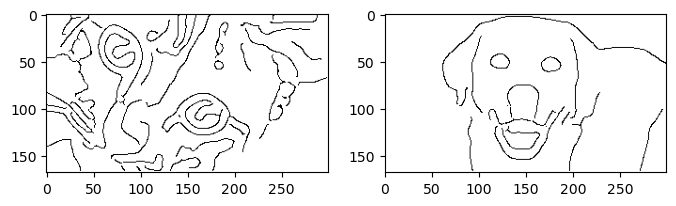

In [23]:
from skimage.feature import canny

cat_edges = canny(cgs,sigma=3)
dog_edges = canny(dgs,sigma=3)

fig = plt.figure(figsize=(8,4))
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(cat_edges,cmap='binary')
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(dog_edges,cmap='binary')

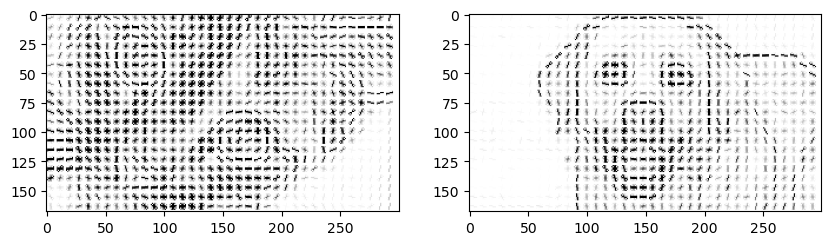

In [33]:
from skimage.feature import hog
from skimage import exposure

fd_cat, cat_hog = hog(cgs, orientations=8, pixels_per_cell=(8, 8),
                    cells_per_block=(3, 3), visualize=True)


fd_dog,dog_hog = hog(dgs,orientations=8,pixels_per_cell=(8,8),
                     cells_per_block=(3,3),visualize=True)

cat_hogs = exposure.rescale_intensity(cat_hog,in_range=(0,0.04))
dog_hogs = exposure.rescale_intensity(dog_hog,in_range=(0,0.04))


fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(cat_hogs,cmap='binary')
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(dog_hogs,cmap='binary')

In [35]:
print(fd_cat,fd_cat.shape)

[0.03784089 0.01940157 0.15044006 ... 0.         0.         0.        ] (47880,)


In [36]:
!pip install mahotas

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.9 MB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.0 MB/s eta 0:00:00


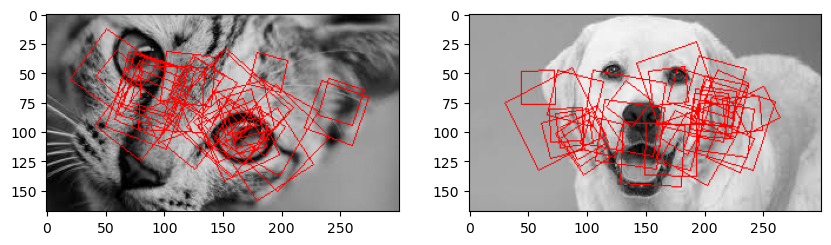

In [39]:
from mahotas.features import surf
import mahotas as mh

cat_mh = mh.colors.rgb2gray(cat)
dog_mh = mh.colors.rgb2gray(dog)

cat_surf = surf.surf(cat_mh,nr_octaves=8,nr_scales=16,initial_step_size=1,threshold=0.1,max_points=50)
dog_surf = surf.surf(dog_mh,nr_octaves=8,nr_scales=16,initial_step_size=1,threshold=0.1,max_points=54)


fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(surf.show_surf(cat_mh,cat_surf))
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(surf.show_surf(dog_mh,dog_surf))

In [42]:
cat_surf_fds = surf.dense(cat_mh,spacing=10)
dog_surf_fds = surf.dense(dog_mh,spacing=10)

In [44]:
from sklearn.cluster import KMeans

k = 20
km = KMeans(k,n_init=100,max_iter=100)

surf_fd_features = np.array([cat_surf_fds,dog_surf_fds])
km.fit(np.concatenate(surf_fd_features))

vbow_features=  []
for feature_desc in surf_fd_features:
    labels = km.predict(feature_desc)
    vbow = np.bincount(labels,minlength=k)
    vbow_features.append(vbow)
    
vbow_df = pd.DataFrame(vbow_features)
pd.concat([df,vbow_df],axis=1)




c:\Users\mojta_tok6stl\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,Image,0,1,2,3,4,5,6,7,8,...,10,11,12,13,14,15,16,17,18,19
0,Cat,14,12,12,2,1,11,2,13,1,...,0,1,8,7,3,9,19,2,0,11
1,Dog,6,6,9,12,3,10,3,8,2,...,13,5,5,9,2,4,11,4,3,7


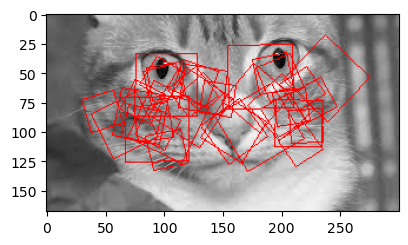

In [46]:
new_cat = io.imread('datasets/new_cat.png')
newcat_mh = mh.colors.rgb2gray(new_cat)
newcat_surf = surf.surf(newcat_mh,nr_octaves=8,nr_scales=16,initial_step_size=1,threshold=1,max_points=50)

fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(surf.show_surf(newcat_mh,newcat_surf))

In [47]:
new_surf_fds = surf.dense(newcat_mh,spacing=10)

labels = km.predict(new_surf_fds)
new_vbow = np.bincount(labels,minlength=k)
pd.DataFrame([new_vbow])


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,14,10,5,0,3,19,3,7,0,18,1,0,11,18,6,8,5,2,0,10


In [49]:
from sklearn.metrics.pairwise import euclidean_distances,cosine_similarity
eucdis = euclidean_distances(new_vbow.reshape(1,-1),vbow_features)
cossin = cosine_similarity(new_vbow.reshape(1,-1),vbow_features)

resuld_df = pd.DataFrame({'EulideanDistance':eucdis[0],
                          'CosineSimilarity':cossin[0]})
pd.concat([df,resuld_df],axis=1)

,Image,EulideanDistance,CosineSimilarity
0,Cat,23.194827,0.840794
1,Dog,26.495283,0.778871


In [ ]:
from keras.models import Sequential
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras import backend as K

In [ ]:
model = Sequential()

model.add(Conv2D(4,(4,4),input_shape=(168,300,3),activation='relu',
                 kernel_initializer='glorot_unifrom'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(4,(4,4),activation='relu'),
          kernel_initializer='glorot_uniform')

In [ ]:
from IPython.display import SVG
from keras.utils.vis_utils import model_to_dot

SVG(model_to_dot(model,show_shapes=True,show_layer_names=True,rankdir='TB').create(prog='dot',format='svg'))

In [ ]:
first_conv_layer = k.function([model.layers[0].input,k.learning_phase()],
                              [model.layers[0].output])

seconde_conv_layer = k.function([model.layers[0].input,k.learning_phase()],
                                [model.layers[0].output()])

In [ ]:

catr = cat.reshape(1,168,300,3)

first_conv_features = first_conv_layer([catr])[0][0]
seconde_conv_layer = seconde_conv_layer([catr])[0][0]


fig = plt.figure(figsize=(14,4))
ax1 = fig.add_subplot(2,4,1)
ax1.imshow(first_conv_features[:,:,0])
ax2 = fig.add_subplot(2,4,2)
ax2.imshow(first_conv_features[:,:,1])
ax3 = fig.add_subplot(2,4,3)
ax3.imshow(first_conv_features[:,:,2])
ax4 = fig.add_subplot(2,4,4)
ax4.imshow(first_conv_features[:,:,3])


ax5 = fig.add_subplot(2,4,5)
ax5.imshow(seconde_conv_layer[:,:,0])
ax6 = fig.add_subplot(2,4,6)
ax6.imshow(seconde_conv_layer[:,:,1])
ax7 = fig.add_subplot(2,4,7)
ax7.imshow(seconde_conv_layer[:,:,2])
ax8 = fig.add_subplot(2,4,8)
ax8.imshow(seconde_conv_layer[:,:,3])



In [ ]:
sampel_featurse = np.round(np.array(first_conv_features[:,:,1],dtype='float'),2)
print(sampel_featurse)
print(sampel_featurse.shape)
